In [29]:
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import MessagesState
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel
load_dotenv()

True

In [2]:
# load the pdf  files
pdf_loader = PyPDFLoader("../season11/evs_oil_price_shock.pdf")
raw_docs = pdf_loader.load()

In [3]:
#2 spilt doc into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = text_splitter.split_documents(raw_docs)
print(len(chunks))

51


In [10]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embedding =  GoogleGenerativeAIEmbeddings(model="text-embedding-3-small")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [4]:
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

vectorstore = Chroma(
    collection_name="rag_base",          # not "collection_metadata"
    embedding_function=embedding,
    persist_directory="./chroma_db",
)

vectorstore.add_documents(chunks)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

C:\Users\Deepam\AppData\Local\Temp\ipykernel_11900\853918670.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI
class AgenticRAGState(MessagesState):
    query : str
    retriever_docs : list[Document] | None
    context : str | None
    generation : str
    need_retrieval : bool
llm = ChatGoogleGenerativeAI(model="models/gemini-3.5-flash",     # higher quality
    temperature=0)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [31]:
class RouteDecision(BaseModel):
    need_retrieval:bool

In [41]:
from langchain_core.prompts import PromptTemplate
def route_question(state: AgenticRAGState):
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})
    return {"need_retrieval": decision.need_retrieval}

In [39]:
route_question(AgenticRAGState(query="What is the impact of oil price shocks on the economy?"))

AttributeError: 'RouteDecision' object has no attribute 'needs_retrieval'

In [19]:
from google import genai
client = genai.Client(api_key="AQ.Ab8RN6Iys-pGaIQC6dUIi8oS7lUr1NSBt8UzgYLga2Qmi65BgA")  # or the same client you used
for m in client.models.list():
    if "generateContent" in str(m.supported_actions):
        print(m.name)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gemini-robotics-er-2-preview
models/gemini-2.5-computer-use-p

In [40]:
def retrieve(state : AgenticRAGState):
    docs = retriever.invoke(state['query'])
    if docs:
        context = "\n\n".join([docs.page_content for doc in docs])
        return {"retriever_docs" : docs, "context" : context}

In [42]:
def generate(state: AgenticRAGState):
    query = state['query']
    context = state['context']
    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        chain = prompt_template | llm | StrOutputParser()
        response = chain.invoke({"query": query, "context": context})
        return {"generation": response}
    else:
        print('inside else part')
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        chain = prompt_template | llm | StrOutputParser()
        response = chain.invoke({"query": query, "context": None})
        return {"generation": response}

In [44]:
generate(AgenticRAGState(query="who is CM of Odissa?", context=None))

inside else part


{'generation': 'The current Chief Minister of Odisha is **Mohan Charan Majhi**. He assumed office on June 12, 2024, representing the Bharatiya Janata Party (BJP).'}

In [46]:
from typing import Literal

def route_after_classification(state : AgenticRAGState) -> Literal["retrieve", "generate"]:
    return "retrieve" if state['need_retrieval'] else "generate"

In [49]:
graph_builder = StateGraph(AgenticRAGState)
graph_builder.add_node("needs_retrieval", route_question)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "needs_retrieval")
graph_builder.add_conditional_edges("needs_retrieval", route_after_classification)
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [50]:
graph = graph_builder.compile()

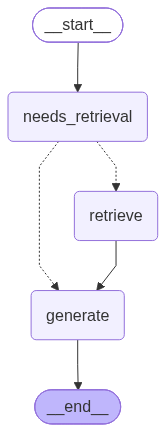

: 

In [ ]:
graph